# Experiment 3: Let $\gamma > 0$ and have two cases: UDE learns parameters, other assumes known

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

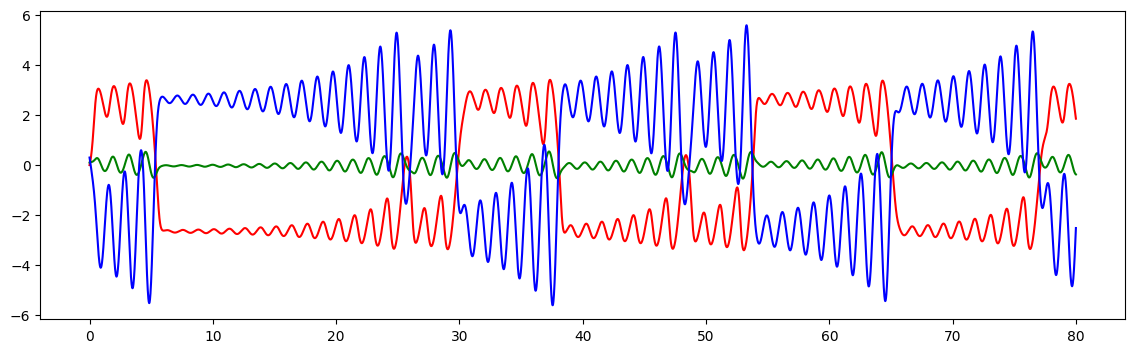

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (20, 30, 0.32, 0.03, (1+-1.2))

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 80

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0, 0.1, 0.3))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))
stepper = dfx.PIDController(rtol=1e-6, atol=1e-9)
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, 
                      args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper,)

fig, ax = plt.subplots(figsize=(14, 4))
plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [ ]:
T_MAX = 30
@eqx.filter_jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0, 0.1, 0.3))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                max_steps=4096*10)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.1, 0.2, 0.4))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                              max_steps=4096*10)

    x_val = sol_val.ys[::3]
    t_val = sol_val.ts[::3]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [11]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


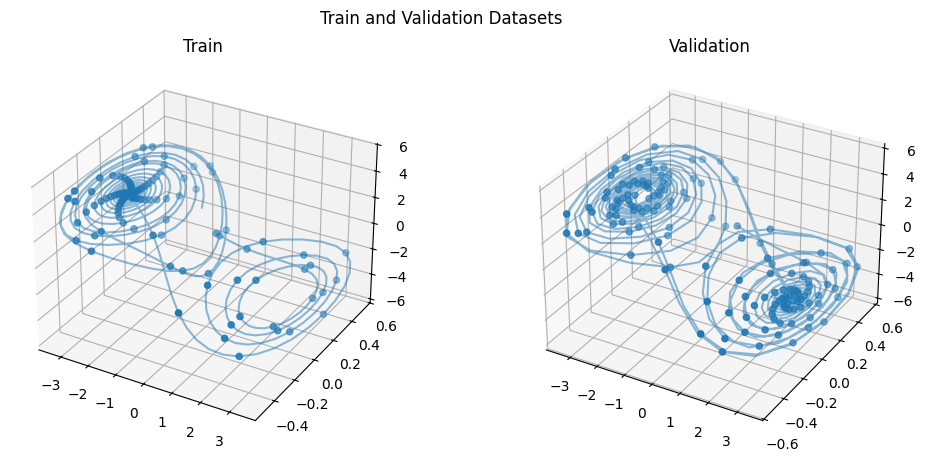

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

## Modeling

In [15]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [16]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [17]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )

In [18]:
class ChuaUDEX_UnknownParameters_PEM(eqx.Module):
    # Here the parameters alpha, beta, gamma are unknown and can be changed
    net: eqx.nn.MLP
    alpha: jnp.ndarray
    beta: jnp.ndarray
    gamma: jnp.ndarray
    K: jax.Array

    def __init__(self, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = jax.random.normal(key, shape=()) # Initialize randomly with uniform distribution
        self.beta = jax.random.normal(key, shape=())
        self.gamma = jax.random.normal(key, shape=())
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )

## Training

In [10]:
def solve_ude_light(model, y0, ts, obs_fun):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-6, atol=1e-9)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper,
        args=obs_fun,
        max_steps=4096*2*2
    )
    return sol.ys



In [11]:
@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_light(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [204]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	2.2192e+00	2.5418e+00
1	1.9048e+00	---
2	1.6264e+00	---
3	1.4152e+00	---
4	1.2940e+00	---
5	1.2528e+00	---
6	1.2463e+00	---
7	1.2199e+00	---
8	1.1546e+00	---
9	1.0619e+00	---
10	9.6574e-01	---
11	8.8957e-01	---
12	8.4444e-01	---
13	8.1114e-01	---
14	7.6675e-01	---
15	7.1132e-01	---
16	6.6111e-01	---
17	6.2823e-01	---
18	6.1870e-01	---
19	6.2607e-01	---
20	6.3730e-01	---
21	6.4348e-01	---
22	6.4440e-01	---
23	6.4603e-01	---
24	6.5405e-01	---
25	6.6049e-01	---
26	6.5492e-01	---
27	6.4360e-01	---
28	6.3455e-01	---
29	6.2876e-01	---
30	6.2302e-01	---
31	6.1611e-01	---
32	6.0920e-01	---
33	6.0468e-01	---
34	6.0398e-01	---
35	6.0562e-01	---
36	6.0663e-01	---
37	6.0672e-01	---
38	6.0706e-01	---
39	6.0797e-01	---
40	6.0810e-01	---
41	6.0635e-01	---
42	6.0382e-01	---
43	6.0182e-01	---
44	6.0053e-01	---
45	5.9899e-01	---
46	5.9720e-01	---
47	5.9617e-01	---
48	5.9610e-01	---
49	5.9613e-01	---
50	5.9569e-01	---
51	5.9528e-01	---
52	5.9513e-01	---
53	5.9452e-01	---
54	5.9326e-01	---
55	5.9217e-01

In [205]:
key = jr.PRNGKey(0)

ude_pem_unknown = ChuaUDEX_UnknownParameters_PEM([0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.02
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem_unknown, eqx.is_inexact_array))

train_losses_pem_unk = []
val_losses_pem_unk = []

alphas = []
betas = []
gammas = []

for i in range(0, n_epochs):
    ude_pem_unknown, opt_state, loss = train_step(ude_pem_unknown, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = None

    train_losses_pem_unk.append(loss)
    alphas.append(ude_pem_unknown.alpha)
    betas.append(ude_pem_unknown.beta)
    gammas.append(ude_pem_unknown.gamma)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem_unknown, x_val[0], x_val, t_val, linear_interp_jit_val)[0]
        val_losses_pem_unk.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.9882e+00	2.3652e+00
1	1.6560e+00	---
2	1.4260e+00	---
3	3.0345e+00	---
4	1.2337e+00	---
5	1.1779e+00	---
6	1.1328e+00	---
7	1.0972e+00	---
8	1.0692e+00	---
9	1.0463e+00	---
10	1.0274e+00	---
11	1.0145e+00	---
12	1.0017e+00	---
13	9.9176e-01	---
14	9.8437e-01	---
15	9.7678e-01	---
16	9.6953e-01	---
17	9.6530e-01	---
18	9.5954e-01	---
19	9.5516e-01	---
20	9.5181e-01	---
21	9.4720e-01	---
22	9.4393e-01	---
23	9.4078e-01	---
24	9.3701e-01	---
25	9.3440e-01	---
26	9.3112e-01	---
27	9.2808e-01	---
28	9.2533e-01	---
29	9.2257e-01	---
30	9.1986e-01	---
31	9.1739e-01	---
32	9.1479e-01	---
33	9.1229e-01	---
34	9.1009e-01	---
35	9.0772e-01	---
36	9.0459e-01	---
37	9.0234e-01	---
38	9.0037e-01	---
39	8.9727e-01	---
40	8.9464e-01	---
41	8.9215e-01	---
42	8.8995e-01	---
43	8.8748e-01	---
44	8.8731e-01	---
45	8.8958e-01	---
46	8.8256e-01	---
47	8.8333e-01	---
48	8.7797e-01	---
49	8.7472e-01	---
50	8.7353e-01	---
51	8.6979e-01	---
52	8.6881e-01	---
53	8.6644e-01	---
54	8.6266e-01	---
55	8.6106e-01

In [193]:
eqx.tree_serialise_leaves("./models_weights/31_7_ude.eqx", ude_pem)
eqx.tree_serialise_leaves("./models_weights/31_7_ude_unknown_params.eqx", ude_pem_unknown)


## Some plots

In [206]:
alphas = jnp.array(alphas)
betas = jnp.array(betas)
gammas = jnp.array(gammas)

jnp.save("./models_weights/31_7_alphas.jnp", alphas)
jnp.save("./models_weights/31_7_betas.jnp", betas)
jnp.save("./models_weights/31_7_gammas.jnp", gammas)
# ALPHA, BETA, GAMMA, A, C = (20, 30, 0.32, 0.03, (1+-1.2))

In [224]:
x_max = jnp.max(jnp.abs(x_train[:, 0]))

x_range = jnp.arange(-x_max, x_max, 0.01)

y_pem = []
y_pem_unknown = []
y_true = []

for x in x_range:
    y_pem.append(ude_pem.net(x))
    y_pem_unknown.append(ude_pem_unknown.net(x))
    y_true.append(A*x**3 + C*x)

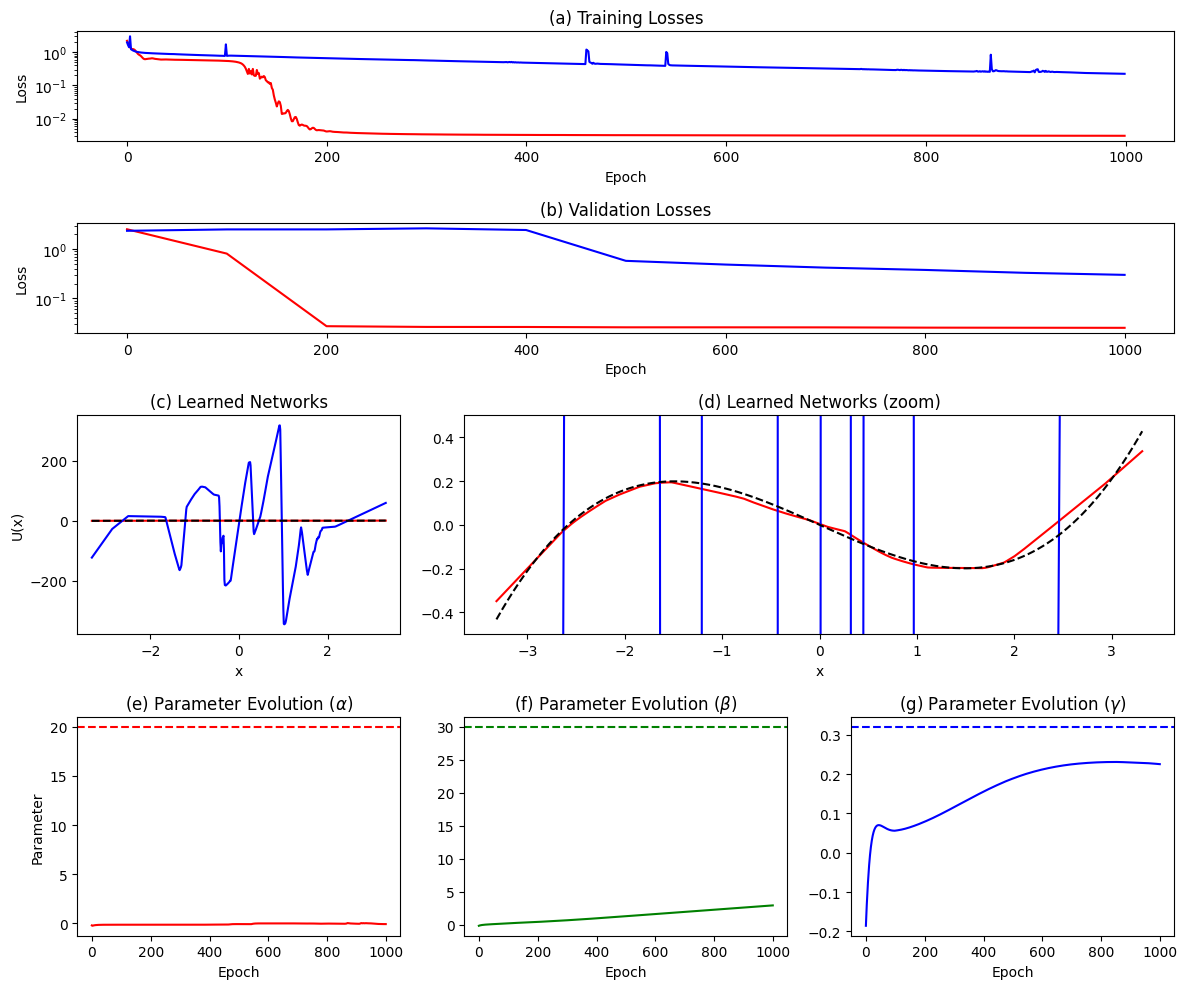

In [323]:
# Compare two models: print the loss curves and the learned function in [-|xmax|, |xmax|]

mosaic = [
    ['training', 'training', 'training'],
    ['validation', 'validation', 'validation'],
    ['functions', 'functions_zoom', 'functions_zoom'],
    ['parameters_a', 'parameters_b', 'parameters_c']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(12, 10), height_ratios=[1, 1, 2, 2])

axes['training'].semilogy(range(1000), train_losses_pem, color='red')
axes['training'].semilogy(range(1000), train_losses_pem_unk[:1000], color='blue')
axes['validation'].semilogy(100*jnp.arange(0,11,1), val_losses_pem, color='red')
axes['validation'].semilogy(100*jnp.arange(0,11,1), val_losses_pem_unk[:11], color='blue')

axes['functions'].plot(x_range, y_pem, color = 'red')
axes['functions'].plot(x_range, y_pem_unknown, color='blue')
axes['functions'].plot(x_range, y_true, color='k', linestyle="--")

axes['functions_zoom'].plot(x_range, y_pem, color = 'red')
axes['functions_zoom'].plot(x_range, y_pem_unknown, color='blue')
axes['functions_zoom'].plot(x_range, y_true, color='k', linestyle="--")
axes['functions_zoom'].set_ylim(-0.5, 0.5)

axes['parameters_a'].plot(range(1000), alphas[:1000], color='red')
axes['parameters_b'].plot(range(1000), betas[:1000], color='green')
axes['parameters_c'].plot(range(1000), gammas[:1000], color='blue')

axes['parameters_a'].axhline(20, color='red', linestyle="--")
axes['parameters_b'].axhline(30, color='green', linestyle='--')
axes['parameters_c'].axhline(0.32, color='blue', linestyle='--')

axes['training'].set_title("(a) Training Losses")
axes['validation'].set_title("(b) Validation Losses")
axes['functions'].set_title("(c) Learned Networks")
axes['functions_zoom'].set_title("(d) Learned Networks (zoom)")
axes['parameters_a'].set_title(r"(e) Parameter Evolution ($\alpha$)")
axes['parameters_b'].set_title(r"(f) Parameter Evolution ($\beta$)")
axes['parameters_c'].set_title(r"(g) Parameter Evolution ($\gamma$)")

axes['parameters_a'].set_xlabel("Epoch")
axes['parameters_b'].set_xlabel("Epoch")
axes['parameters_c'].set_xlabel("Epoch")
axes['parameters_a'].set_ylabel("Parameter")

axes['functions_zoom'].set_xlabel('x')
axes['functions'].set_xlabel('x')
axes['functions'].set_ylabel('U(x)')

axes['training'].set_xlabel("Epoch")
axes['validation'].set_xlabel("Epoch")
axes['training'].set_ylabel("Loss")
axes['validation'].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [ ]:
# Study the model with unknown parameters: loss curves, learned function and evolution of the parameters

In [253]:
alphas = list(alphas)
betas = list(betas)
gammas = list(gammas)

In [254]:
# Train the model with unknown parameters even further, to see if it can manage to converge towards the true parameters sooner or later
for i in range(0, 9000):
    ude_pem_unknown, opt_state, loss = train_step(ude_pem_unknown, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = None

    train_losses_pem_unk.append(loss)
    alphas.append(ude_pem_unknown.alpha)
    betas.append(ude_pem_unknown.beta)
    gammas.append(ude_pem_unknown.gamma)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem_unknown, x_val[0], x_val, t_val, linear_interp_jit_val)[0]
        val_losses_pem_unk.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

0	2.2435e-01	3.0037e-01
1	2.2415e-01	---
2	2.2393e-01	---
3	2.2367e-01	---
4	2.2346e-01	---
5	2.2324e-01	---
6	2.2300e-01	---
7	2.2277e-01	---
8	2.2256e-01	---
9	2.2233e-01	---
10	2.2211e-01	---
11	2.2189e-01	---
12	2.2166e-01	---
13	2.2144e-01	---
14	2.2122e-01	---
15	2.2098e-01	---
16	2.2077e-01	---
17	2.2054e-01	---
18	2.2032e-01	---
19	2.2010e-01	---
20	2.1986e-01	---
21	2.1965e-01	---
22	2.1942e-01	---
23	2.1923e-01	---
24	2.1899e-01	---
25	2.1879e-01	---
26	2.1857e-01	---
27	2.1836e-01	---
28	2.1815e-01	---
29	2.1793e-01	---
30	2.1772e-01	---
31	2.1751e-01	---
32	2.1730e-01	---
33	2.1709e-01	---
34	2.1687e-01	---
35	2.1667e-01	---
36	2.1646e-01	---
37	2.1626e-01	---
38	2.1604e-01	---
39	2.1583e-01	---
40	2.1562e-01	---
41	2.1541e-01	---
42	2.1523e-01	---
43	2.1500e-01	---
44	2.1479e-01	---
45	2.1460e-01	---
46	2.1440e-01	---
47	2.1419e-01	---
48	2.1398e-01	---
49	2.1377e-01	---
50	2.1361e-01	---
51	2.1338e-01	---
52	2.1317e-01	---
53	2.1297e-01	---
54	2.1277e-01	---
55	2.1257e-01

In [255]:
eqx.tree_serialise_leaves("./models_weights/31_7_ude_unknown_params_further.eqx", ude_pem_unknown)
alphas = jnp.array(alphas)
betas = jnp.array(betas)
gammas = jnp.array(gammas)

jnp.save("./models_weights/31_7_alphas_extended", alphas)
jnp.save("./models_weights/31_7_betas_extended", betas)
jnp.save("./models_weights/31_7_gammas_extended", gammas)
# ALPHA, BETA, GAMMA, A, C = (20, 30, 0.32, 0.03, (1+-1.2))

In [15]:
x_max = jnp.max(jnp.abs(x_train[:, 0]))

x_range = jnp.arange(-x_max, x_max, 0.01)

y_pem = []
y_pem_unknown = []
y_true = []

for x in x_range:
    y_pem.append(ude_pem.net(x))
    y_pem_unknown.append(ude_pem_unknown.net(x))
    y_true.append(A*x**3 + C*x)

In [41]:
import jax.numpy as jnp
import numpy as np

data = np.genfromtxt(
    "./losses/31_7_losses.txt",
    delimiter="\t",     
    missing_values="---", # set --- as NaN
    filling_values=np.nan
)

data_jax = jnp.array(data)
data_jax = data_jax.at[:, 0].set(jnp.arange(0, 10000, 1))

clean_rows = data_jax[~jnp.isnan(data_jax).any(axis=1)]

train_losses_pem_unk = data_jax[:, 1]
val_losses_pem_unk = clean_rows[:, 1]

alphas = jnp.load("./models_weights/31_7_alphas_extended.npy")
betas = jnp.load("./models_weights/31_7_betas_extended.npy")
gammas = jnp.load("./models_weights/31_7_gammas_extended.npy")


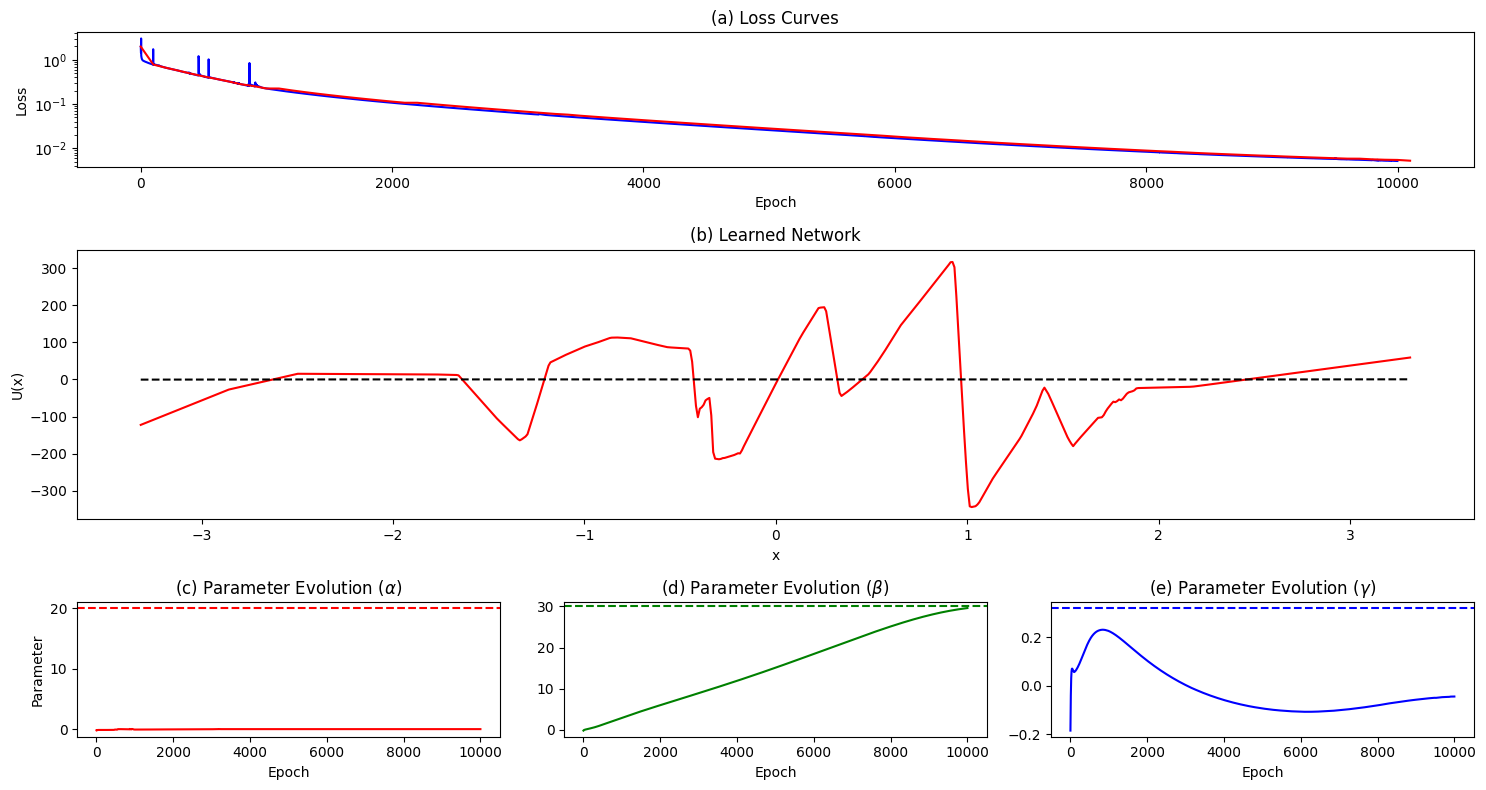

In [50]:
mosaic = [
    ['loss_curve', 'loss_curve', 'loss_curve'],
    ['fun_plot', 'fun_plot', 'fun_plot'],
    ['alpha', 'beta', 'gamma']
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(15, 8), height_ratios=[0.5, 1, 0.5])

axes['loss_curve'].semilogy(range(10000), train_losses_pem_unk, color='blue')
axes['loss_curve'].semilogy(100*jnp.arange(0, 102, 1), val_losses_pem_unk, color='red')

# axes['loss_curve'].axhline(train_losses_pem[-1], color='blue', linestyle=":", alpha=1, linewidth=2.5)
# axes['loss_curve'].axhline(val_losses_pem[-1], color='red', linestyle=":", alpha=1, linewidth=2.5)

axes['loss_curve'].set_title("(a) Loss Curves")
axes['loss_curve'].set_xlabel("Epoch")
axes['loss_curve'].set_ylabel("Loss")

axes['fun_plot'].set_title("(b) Learned Network")
axes['fun_plot'].plot(x_range, y_pem_unknown, color='red')
axes['fun_plot'].plot(x_range, y_true, color='k', linestyle="--")
axes['fun_plot'].set_xlabel("x")
axes['fun_plot'].set_ylabel("U(x)")

axes['alpha'].plot(range(10000), alphas, color='red')
axes['beta'].plot(range(10000), betas, color='green')
axes['gamma'].plot(range(10000), gammas, color='blue')

axes['alpha'].axhline(20, color='red', linestyle="--")
axes['beta'].axhline(30, color='green', linestyle='--')
axes['gamma'].axhline(0.32, color='blue', linestyle='--')

axes['alpha'].set_xlabel("Epoch")
axes['beta'].set_xlabel("Epoch")
axes['gamma'].set_xlabel("Epoch")
axes['alpha'].set_ylabel("Parameter")

axes['alpha'].set_title(r"(c) Parameter Evolution ($\alpha$)")
axes['beta'].set_title(r"(d) Parameter Evolution ($\beta$)")
axes['gamma'].set_title(r"(e) Parameter Evolution ($\gamma$)")

plt.tight_layout()
plt.show()

In [45]:
ude_pem_unknown.beta

Array(29.60272326, dtype=float64)

In [ ]:
# Load models

In [19]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)
ude_pem_unknown = ChuaUDEX_UnknownParameters_PEM([0.9, 0.6, 0.6], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_7_ude.eqx", ude_pem)
ude_pem_unknown = eqx.tree_deserialise_leaves("./models_weights/31_7_ude_unknown_params_further.eqx", ude_pem_unknown)


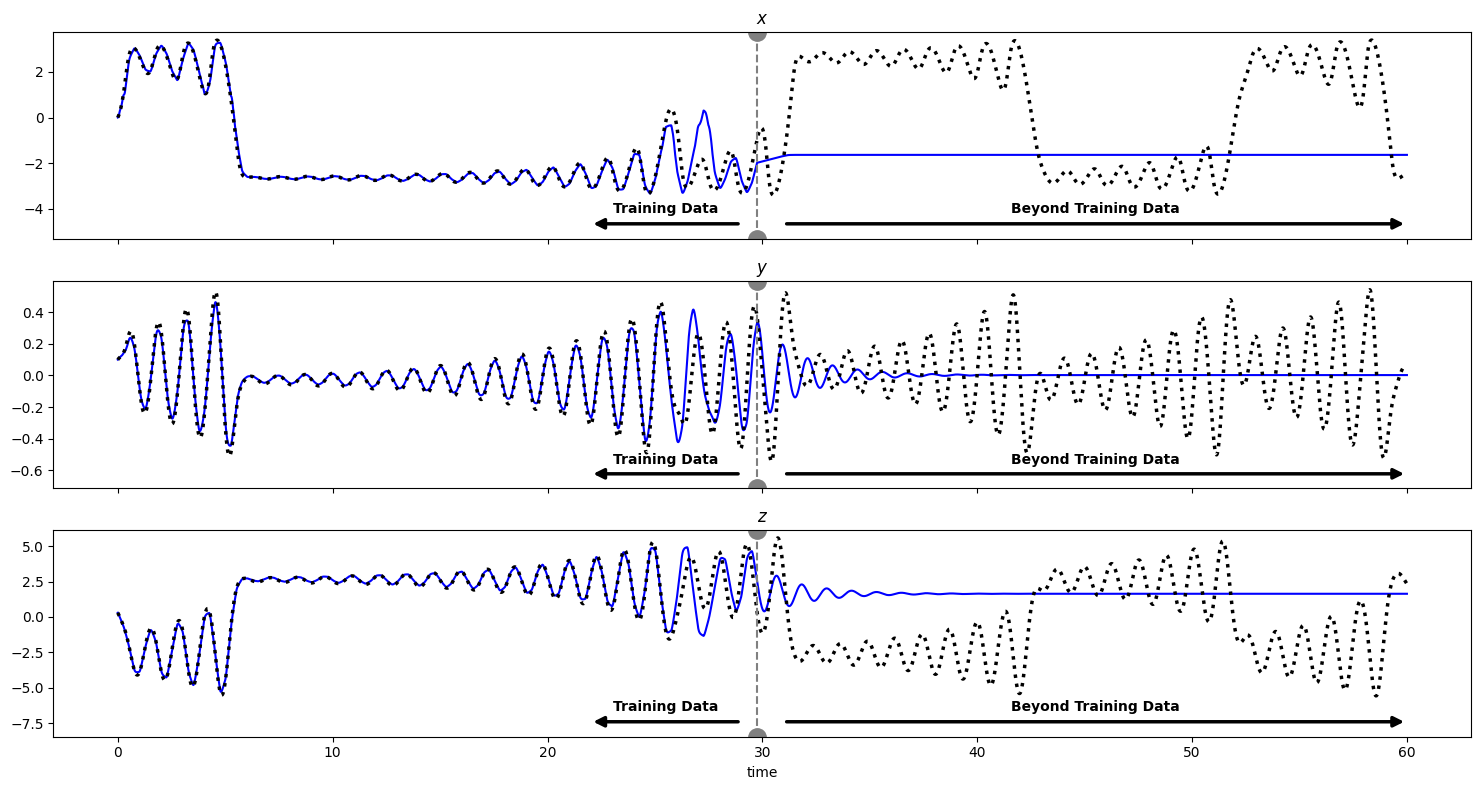

In [22]:
# Simulate them up to T = 40 and compare it with true trajectory

term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)
term_ude_unk = dfx.ODETerm(ude_pem_unknown)

T_MAX = 60

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.001)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.001, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final_unk = dfx.diffeqsolve(term_ude_unk, solver, t0=0, t1=T_MAX, dt0=0.001, y0=y0, args=linear_interp, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys

for i in range(3):
    plt.sca(axes[i])
    # plt.plot(t_eval, traj_final[:, i], color='red',)
    plt.plot(t_eval, traj_final_unk[:, i], color='blue',)
    plt.plot(t_eval, traj_true[:, i], color='k', linestyle=':', linewidth=2.5)
    plt.axvline(t_train[-1], color="grey", label="Last Training Set Point", marker=".", markersize=25, linestyle="--")
    plt.title(f"${var_dict[i]}$")

    y_min = min(jnp.min(traj_final_unk[:, i]), jnp.min(traj_final_unk[:, i]))
    plt.ylim(y_min * 1.6, None)
    
    plt.annotate('', xy=(T_MAX, y_min+y_min*0.4), xytext=(31, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(31+T_MAX), y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold")

    plt.annotate('', xy=(29, y_min+y_min*0.4), xytext=(22, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(25.5, y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold" )

plt.xlabel("time")

plt.tight_layout()
plt.show()

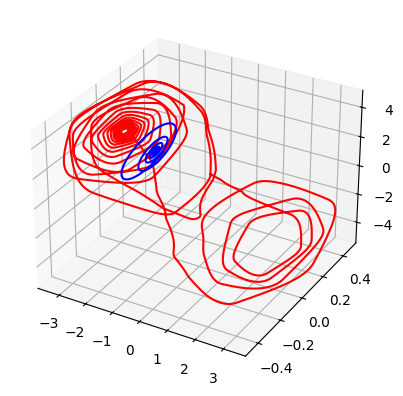

In [77]:
t = sol.ts          # shape (N,)
x = traj_final_unk[:, 0]
y = traj_final_unk[:, 1]
z = traj_final_unk[:, 2]

fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

mask = (t>=30)

i0 = np.argmax(mask)
ax.plot3D(x[:i0+1], y[:i0+1], z[:i0+1], color="red")
ax.plot3D(x[i0:], y[i0:], z[i0:], color="blue")


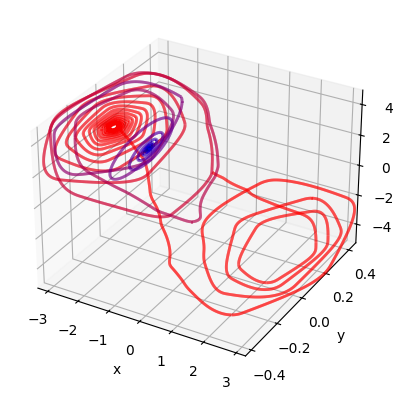

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

t = np.asarray(sol.ts)          # shape (N,)
x = traj_final_unk[:, 0]
y = traj_final_unk[:, 1]
z = traj_final_unk[:, 2]

fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))

# Build 3D line segments
points = np.column_stack((x, y, z)).reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Time value for each segment
segment_t = 0.5 * (t[:-1] + t[1:])

# Smooth transition around t = 30
transition = 30
width = 3.0   # larger = more gradual transition

# alpha goes smoothly from 0 to 1
alpha = 1 / (1 + np.exp(-(segment_t - transition) / width))

# Red -> Blue colors
colors = np.column_stack([
    1 - alpha,              # red channel
    np.zeros_like(alpha),   # green channel
    alpha,                  # blue channel
    np.ones_like(alpha)     # opacity
])

lc = Line3DCollection(segments, colors=colors, linewidth=2)
ax.add_collection3d(lc)

# Axes limits
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()